In [1]:
import bw2data, bw2io, bw2calc
import numpy as np
import os
import re
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

### static LCI +  three GWP
- GWP100
- pGWP-fixed vs. dp-CO2 

In [2]:
wind  = pd.read_excel("dp-LCI_output/staticLCI_(p)GWP100/wind_CN_US_staticLCI_threeGWP100.xlsx")
#hydro = pd.read_excel("dp-LCI_output/staticLCI_(p)GWP100/hydro_run-of-river_CN_US_staticLCI_threeGWP100.xlsx")
hydro = pd.read_excel("dp-LCI_output/staticLCI_(p)GWP100/hydro_reservoir_CN-asRoW_US-asQC_staticLCI_threeGWP100.xlsx")
pv    = pd.read_excel("dp-LCI_output/staticLCI_(p)GWP100/PV_CN_US_staticLCI_threeGWP100.xlsx")

In [3]:
def tidy(df, tech_label):
    parts = df["Activity"].str.split(", ", expand=True)
    out = df.copy()
    out["Technology"] = tech_label
    out["Country"]    = parts[3].str[:2]
    out["SSP"]        = parts[4]
    out["Year"]       = parts[5].astype(int)
    return out[["Technology", "Country", "SSP", "Year",
                "gwp100", "pGWP100_fixedCO2", "pGWP100_dpCO2"]]

all_df = pd.concat(
    [tidy(wind,  "Wind"),
     tidy(hydro, "Hydro"),
     tidy(pv,    "PV")],
    ignore_index=True,
)

# Keep only 2030 & 2050
df = all_df[all_df["Year"].isin([2030, 2050])].copy()

# long format over metrics
metric_cols = ["gwp100", "pGWP100_fixedCO2", "pGWP100_dpCO2"]
df_long = df.melt(
    id_vars=["Technology", "Country", "SSP", "Year"],
    value_vars=metric_cols,
    var_name="Metric",
    value_name="Score",
)

df_long


,Technology,Country,SSP,Year,Metric,Score
0,Wind,CN,SSP1-VLLO,2030,gwp100,0.036905
1,Wind,CN,SSP1-VLLO,2050,gwp100,0.017832
2,Wind,CN,SSP2-M,2030,gwp100,0.037723
3,Wind,CN,SSP2-M,2050,gwp100,0.031185
4,Wind,CN,SSP5-H,2030,gwp100,0.038734
...,...,...,...,...,...,...
103,PV,US,SSP1-VLLO,2050,pGWP100_dpCO2,0.006184
104,PV,US,SSP2-M,2030,pGWP100_dpCO2,0.020048
105,PV,US,SSP2-M,2050,pGWP100_dpCO2,0.012654
106,PV,US,SSP5-H,2030,pGWP100_dpCO2,0.020952


#### adding:  dpLCI + pGWP-fixedCO2

In [4]:

#with open("dp-LCI_output/dpLCI_pGWP-fixed_pickle/hydro_dp_results_MY2030_2050.pkl","rb") as f:
with open("dp-LCI_output/dpLCI_pGWP-fixed_pickle/hydro_v2_reservoir_dp_region_harmonized.pkl","rb") as f:
    hydro_dp = pickle.load(f)    

with open("dp-LCI_output/dpLCI_pGWP-fixed_pickle/PV_dp_results_MY2030_2050.pkl","rb") as f:
    pv_dp = pickle.load(f)

with open("dp-LCI_output/dpLCI_pGWP-fixed_pickle/wind_dp_results_allMY.pkl","rb") as f:
    wind_dp = pickle.load(f)


# extract the new dp metrics and produce a DataFrame with exact columns:
# Activity, Technology, Country, SSP, Year, Metric, Score
# ONLY WANNA 2030 & 2050 as two MY:: 

def extract_from_dp_dict(dp_dict):
    rows = []

    # map activity string tech → tidy Technology label
    tech_map = {
        "wind": "Wind",
        "PV": "PV",
        "hydro": "Hydro",
    }

    #####   we need to convert all US-xx / CN-xx country code to just US/CN 
    def collapse_country(region):
        """Collapse ecoinvent/IAM region to CN or US."""
        if region.startswith("US"):
            return "US"
        if region.startswith("CN"):
            return "CN"
        # if you ever have other regions, either return as-is or map them too
        return region

    for act, metrics in dp_dict.items():
        parts = act.split(", ")

        raw_tech = parts[1]              # 'wind' / 'photovoltaic' / 'hydro'
        if raw_tech not in tech_map:
            print(row_tech)
            continue                     # skip unexpected techs

        tech        = tech_map[raw_tech]
        region      = parts[3]           # e.g. 'US-TRE', 'CN-NM'
        country     = collapse_country(region)
        ssp         = parts[4]
        year        = int(parts[5])

        # keep only 2030 & 2050
        if year not in (2030, 2050):
            continue

        for metric_name, value in metrics.items():
            rows.append(
                {
                    "Technology": tech,
                    "Country": country,   # NOW only 'US' or 'CN'
                    "SSP": ssp,
                    "Year": year,
                    "Metric": metric_name,
                    "Score": float(value),
                }
            )

    return pd.DataFrame(rows)



df_hydro_dp = extract_from_dp_dict(hydro_dp)
df_pv_dp    = extract_from_dp_dict(pv_dp)
df_wind_dp  = extract_from_dp_dict(wind_dp)

df_dp = pd.concat([df_hydro_dp, df_pv_dp, df_wind_dp], ignore_index=True)
print(len(df_dp)) # should be 72, so that 72/2(new metric) == 36
df_dp


72


,Technology,Country,SSP,Year,Metric,Score
0,Hydro,CN,SSP1-VLLO,2050,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.053979
1,Hydro,CN,SSP1-VLLO,2050,"full dp-LCI, pGWP100-fixedCO2",0.057714
2,Hydro,US,SSP1-VLLO,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.017909
3,Hydro,US,SSP1-VLLO,2030,"full dp-LCI, pGWP100-fixedCO2",0.017975
4,Hydro,US,SSP2-M,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.017505
...,...,...,...,...,...,...
67,Wind,US,SSP1-VLLO,2030,"full dp-LCI, pGWP100-fixedCO2",0.024138
68,Wind,US,SSP2-M,2050,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.017229
69,Wind,US,SSP2-M,2050,"full dp-LCI, pGWP100-fixedCO2",0.021193
70,Wind,CN,SSP1-VLLO,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.041520


In [5]:
#df_dp 
df_full = pd.concat([df_long, df_dp], ignore_index=True)
#df_full

### now ranking 

In [6]:
# NOW recompute Rank with the two new metrics included
df_full["Rank"] = df_full.groupby(
    ["Country","SSP","Year","Metric"]
)["Score"].rank(method="dense", ascending=True)

df_full

,Technology,Country,SSP,Year,Metric,Score,Rank
0,Wind,CN,SSP1-VLLO,2030,gwp100,0.036905,2.0
1,Wind,CN,SSP1-VLLO,2050,gwp100,0.017832,2.0
2,Wind,CN,SSP2-M,2030,gwp100,0.037723,2.0
3,Wind,CN,SSP2-M,2050,gwp100,0.031185,2.0
4,Wind,CN,SSP5-H,2030,gwp100,0.038734,2.0
...,...,...,...,...,...,...,...
175,Wind,US,SSP1-VLLO,2030,"full dp-LCI, pGWP100-fixedCO2",0.024138,3.0
176,Wind,US,SSP2-M,2050,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.017229,3.0
177,Wind,US,SSP2-M,2050,"full dp-LCI, pGWP100-fixedCO2",0.021193,3.0
178,Wind,CN,SSP1-VLLO,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.041520,2.0


In [7]:
metric_rename = {
    "gwp100": "staticLCI + IPCC-GWP",
    "pGWP100_fixedCO2": "staticLCI + pGWP-fixedCO2",
    "pGWP100_dpCO2": "staticLCI + pGWP-dpCO2",
    "dyn FG LCI static BG p-LCI, pGWP100-fixedCO2": "dyn-FG-LCI + pGWP-fixedCO2",
    "full dp-LCI, pGWP100-fixedCO2": "full dpLCI + pGWP-fixedCO2"
}

In [8]:
df_full["Metric"] = df_full["Metric"].replace(metric_rename)

In [9]:
df_full_sorted = df_full.sort_values([ "SSP","Year", "Country", "Technology"	]) 
df_full_sorted

,Technology,Country,SSP,Year,Metric,Score,Rank
18,Hydro,CN,SSP1-VLLO,2030,staticLCI + IPCC-GWP,0.050523,3.0
54,Hydro,CN,SSP1-VLLO,2030,staticLCI + pGWP-fixedCO2,0.057266,3.0
90,Hydro,CN,SSP1-VLLO,2030,staticLCI + pGWP-dpCO2,0.050021,3.0
130,Hydro,CN,SSP1-VLLO,2030,dyn-FG-LCI + pGWP-fixedCO2,0.057266,3.0
131,Hydro,CN,SSP1-VLLO,2030,full dpLCI + pGWP-fixedCO2,0.057505,3.0
...,...,...,...,...,...,...,...
11,Wind,US,SSP5-H,2050,staticLCI + IPCC-GWP,0.019234,3.0
47,Wind,US,SSP5-H,2050,staticLCI + pGWP-fixedCO2,0.017215,3.0
83,Wind,US,SSP5-H,2050,staticLCI + pGWP-dpCO2,0.019006,3.0
168,Wind,US,SSP5-H,2050,dyn-FG-LCI + pGWP-fixedCO2,0.017215,3.0


In [10]:
df_full_sorted.to_excel("plot_rankshift_hydro_v2_reservoir.xlsx")

#### read in the prepared excel with ranks

In [3]:
df_full_sorted = pd.read_excel("plot_rankshift_hydro_v2_reservoir.xlsx")
df_full_sorted

,Unnamed: 0,Technology,Country,SSP,Year,Metric,Score,Rank
0,18,Hydro,CN,SSP1-VLLO,2030,staticLCI + IPCC-GWP,0.050523,3
1,54,Hydro,CN,SSP1-VLLO,2030,staticLCI + pGWP-fixedCO2,0.057266,3
2,90,Hydro,CN,SSP1-VLLO,2030,staticLCI + pGWP-dpCO2,0.050021,3
3,126,Hydro,CN,SSP1-VLLO,2030,dyn-FG-LCI + pGWP-fixedCO2,0.057266,3
4,127,Hydro,CN,SSP1-VLLO,2030,full dpLCI + pGWP-fixedCO2,0.057505,3
...,...,...,...,...,...,...,...,...
175,11,Wind,US,SSP5-H,2050,staticLCI + IPCC-GWP,0.019234,2
176,47,Wind,US,SSP5-H,2050,staticLCI + pGWP-fixedCO2,0.017215,2
177,83,Wind,US,SSP5-H,2050,staticLCI + pGWP-dpCO2,0.019006,2
178,168,Wind,US,SSP5-H,2050,dyn-FG-LCI + pGWP-fixedCO2,0.017215,2


### updated plot, with a GAP threshold 

#### function

In [2]:
def compute_gap_aware_ranks(scores_by_tech, tech_order, gap_threshold_pct=3.0):
    """
    scores_by_tech: dict {tech: score}
    Returns: dict {tech: rank} where rank=1 is lowest score.
    If adjacent technologies are within gap_threshold_pct, they are treated as tied (same rank).
    """
    # Sort techs by score (ascending = lower GWP is "better"/rank 1)
    items = [(t, scores_by_tech.get(t, np.nan)) for t in tech_order]
    items = [(t, s) for t, s in items if not pd.isna(s)]
    items.sort(key=lambda x: x[1])  # ascending score

    if not items:
        return {t: np.nan for t in tech_order}

    # Initial ranks (dense)
    ranks = {t: None for t in tech_order}
    for idx, (t, s) in enumerate(items):
        ranks[t] = idx + 1

    # Collapse near-ties based on adjacent gaps
    # Compare adjacent sorted pairs
    # rel_gap = |s2-s1|/max(s1,s2)*100
    for k in range(1, len(items)):
        t1, s1 = items[k-1]
        t2, s2 = items[k]
        rel_gap = abs(s2 - s1) / max(s1, s2) * 100.0

        if rel_gap < gap_threshold_pct:
            # tie them: assign both the lower (better) rank
            tied_rank = min(ranks[t1], ranks[t2])
            ranks[t1] = tied_rank
            ranks[t2] = tied_rank

    # Re-densify ranks after ties (optional but cleaner):
    # Convert ranks to sorted unique ranks -> 1..K
    present = [(t, r) for t, r in ranks.items() if r is not None]
    uniq = sorted(set(r for _, r in present))
    remap = {old: new for new, old in enumerate(uniq, start=1)}
    for t, r in present:
        ranks[t] = remap[r]

    # Fill missing techs with NaN
    for t in tech_order:
        if ranks[t] is None:
            ranks[t] = np.nan

    return ranks



In [3]:
# using this updated annotation 
# ============================================================
# Global SSP display mapping (used in ALL plots)
# ============================================================
SSP_LABEL_MAP = {
    "SSP1-VLLO": "SSP1-19",
    "SSP2-M":    "SSP2-45",
    "SSP5-H":    "SSP5-85",
}

def format_ssp(ssp: str) -> str:
    """Return standardized display name for SSP."""
    return SSP_LABEL_MAP.get(ssp, ssp)


def rank_shift_plot_cleanSeparated(
    df_long,
    metric_order,
    metric_labels,
    tech_colors,
    fig_title="Rank shifts across GWP metrics",
    years=(2030, 2050),
    countries=("CN", "US"),
    ssps=("SSP1-VLLO", "SSP2-M", "SSP5-H"),
    lw=3.0,
    sep=0.03,
    anot_off=0.16
):
    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd

    df = df_long.copy()
    df["Rank"] = (
        df.groupby(["Country", "SSP", "Year", "Metric"])["Score"]
          .rank(method="dense", ascending=True)
    )

    dotted_2050 = (0, (1, 3))
    year_ls    = {2030: "solid", 2050: dotted_2050}
    year_alpha = {2030: 1.0, 2050: 0.9}
    zmap = {2030: 5, 2050: 4}

    fig, axes = plt.subplots(
        nrows=len(ssps),
        ncols=len(countries),
        figsize=(12, 12),   # 2nd parameter 10 to 12 -> taller figure
        sharex=True,
        sharey=True,
    )
    plt.subplots_adjust(
        top=0.90,
        bottom=0.18,
        hspace=0.55,         # MORE vertical breathing room
        wspace=0.20,
    )

      
    plt.subplots_adjust(top=0.88, bottom=0.20, hspace=0.35, wspace=0.18)

    x = np.arange(len(metric_order))

    for i, ssp in enumerate(ssps):
        for j, ct in enumerate(countries):
            ax = axes[i, j]
            sub = df[(df["SSP"] == ssp) & (df["Country"] == ct)]

            for tech in ["Hydro", "PV", "Wind"]:
                sub_t = sub[sub["Technology"] == tech]

                for yr in years:
                    tdf = sub_t[sub_t["Year"] == yr]
                    if tdf.empty:
                        continue

                    #y_rank  = tdf.set_index("Metric")["Rank"].reindex(metric_order)
                    #y_score = tdf.set_index("Metric")["Score"].reindex(metric_order)

                    # scores for this panel+year, indexed by metric then technology
                    # we will compute rank per metric using GAP-aware rule
                    tech_list = ["Hydro", "PV", "Wind"]  # your plotting order
                    
                    # score series aligned to metric_order for this tech
                    y_score = tdf.set_index("Metric")["Score"].reindex(metric_order)
                    
                    # Build y_rank from gap-aware ranks at each metric
                    y_rank_vals = []
                    for m in metric_order:
                        # get the 3 tech scores at this metric (for this ct/ssp/yr)
                        sub_m = sub[(sub["Year"] == yr) & (sub["Metric"] == m)]
                        scores_by_tech = {t: float(sub_m[sub_m["Technology"] == t]["Score"].values[0])
                                          for t in tech_list if len(sub_m[sub_m["Technology"] == t]["Score"])}
                    
                        ranks_m = compute_gap_aware_ranks(scores_by_tech, tech_list, gap_threshold_pct=5.0)
                        y_rank_vals.append(ranks_m.get(tech, np.nan))
                    
                    y_rank = pd.Series(y_rank_vals, index=metric_order)

                   

                    shift     = sep if yr == 2030 else -sep
                    y_shifted = y_rank + shift

                    ax.plot(
                        x,
                        y_shifted,
                        linestyle=year_ls[yr],
                        color=tech_colors[tech],
                        alpha=year_alpha[yr],
                        linewidth=lw,
                        marker="x",
                        markersize=7,
                        zorder=zmap[yr],
                    )

                    # ---- BOXED ANNOTATIONS ----
                    for xi, yi, sc in zip(x, y_shifted, y_score):
                        if pd.isna(sc):
                            continue

                        val = sc * 1000.0
                        y_text = yi + anot_off if yr == 2030 else yi - anot_off
                        va     = "bottom" if yr == 2030 else "top"

                        ax.text(
                            xi,
                            y_text,
                            f"{val:.1f}",
                            ha="center",
                            va=va,
                            fontsize=9.5,
                            color="white",
                            bbox=dict(
                                    boxstyle="round,pad=0.18",      # slightly tighter box
                                    facecolor=tech_colors[tech],
                                    edgecolor="black",
                                    linewidth=0.9,
                                    linestyle="solid" if yr == 2030 else "dashed",
                                    alpha=0.8,                     # lets grid & lines breathe
                                ),
                            zorder=10,
                        )

            #ax.set_title(f"{ct}, {ssp}", fontsize=14, pad=8)
            ax.set_title(f"{ct}, {format_ssp(ssp)}", fontsize=13)

            ax.set_xticks(x)

            if i == len(ssps) - 1:
                ax.set_xticklabels(
                    [metric_labels[m] for m in metric_order],
                    rotation=25,
                    ha="right",
                    fontsize=12,
                )
            else:
                ax.set_xticklabels([])

            ax.set_yticks([1, 2, 3])
            ax.set_ylim(0.2, 3.8)
            if j == 0:
                ax.set_ylabel("Rank (1 = lowest GWP)", fontsize=13)

            ax.grid(axis="y", linestyle=":", alpha=0.3)

    # Legend
    handles, labels = [], []
    for tech in ["Hydro", "PV", "Wind"]:
        for yr in years:
            h, = axes[0, 0].plot(
                [],
                [],
                linestyle=year_ls[yr],
                color=tech_colors[tech],
                linewidth=lw,
                marker="x",
                markersize=7,
            )
            handles.append(h)
            labels.append(f"{tech} {yr}")

    fig.legend(
        handles,
        labels,
        title="Technology / Year",
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=6,
        fontsize=12,
        frameon=True,
    )

    fig.suptitle(fig_title, fontsize=16, y=0.97)
    return fig, axes

#### plot 

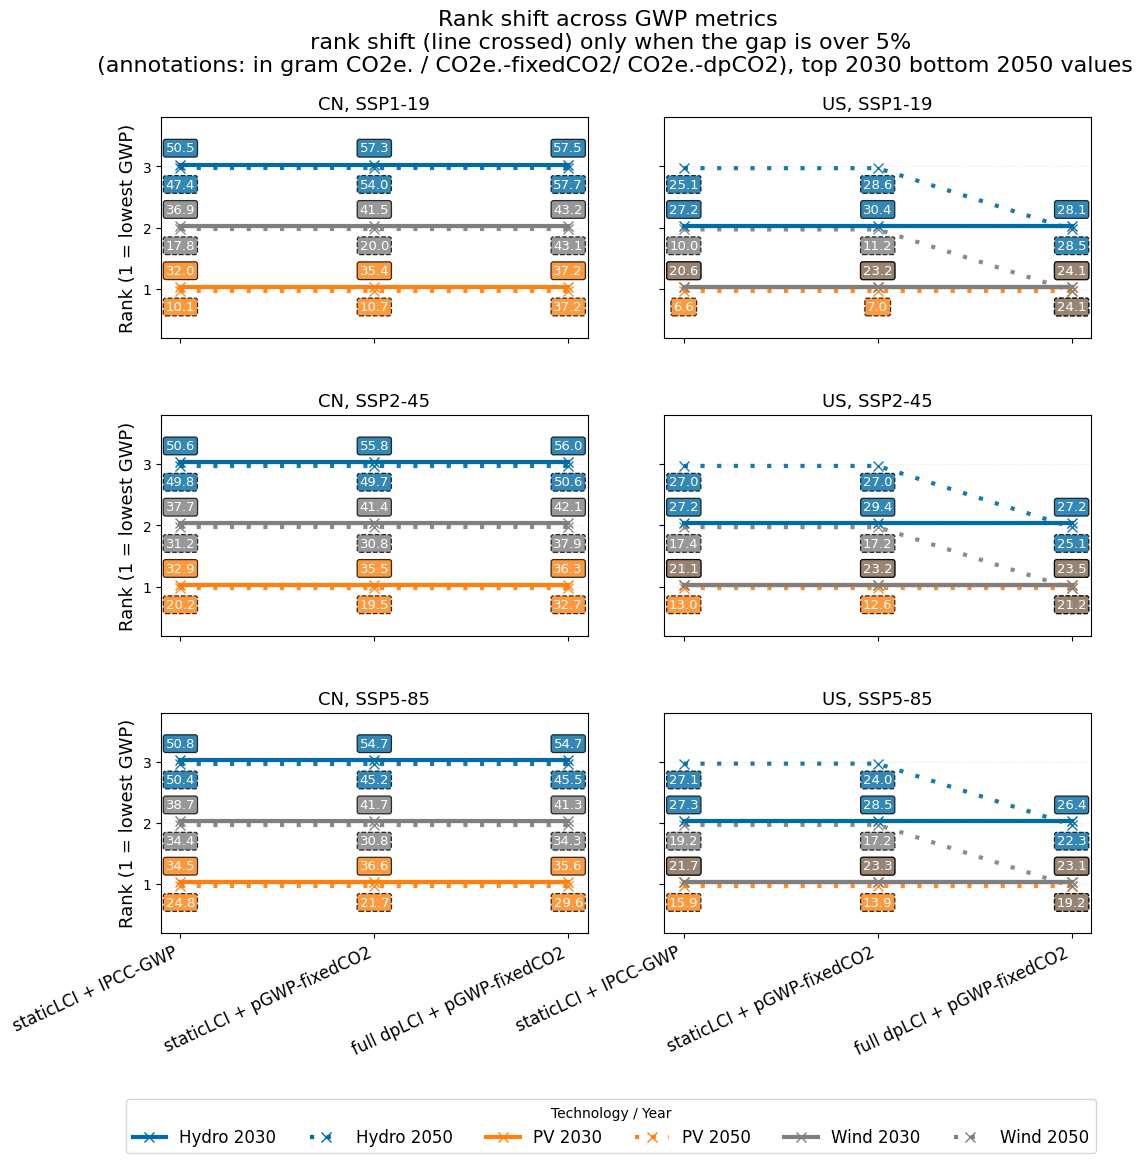

In [4]:

df_full = pd.read_excel("plot_rankshift_hydro_v2_reservoir.xlsx")
#df_full_sorted.head()

# remove the index column if present
if "Unnamed: 0" in df_full.columns:
    df_full = df_full.drop(columns=["Unnamed: 0"])



metric_order = [  #'dyn-FG-LCI + pGWP-fixedCO2', 
        
                  'staticLCI + IPCC-GWP', 
                  'staticLCI + pGWP-fixedCO2', 
                  #'staticLCI + pGWP-dpCO2', 
                 'full dpLCI + pGWP-fixedCO2',
                ]

metric_labels = {
    'staticLCI + IPCC-GWP': 'staticLCI + IPCC-GWP', 
    'staticLCI + pGWP-fixedCO2':'staticLCI + pGWP-fixedCO2', 
    'staticLCI + pGWP-dpCO2': 'staticLCI + pGWP-dpCO2',   
    #'dyn-FG-LCI + pGWP-fixedCO2':'dyn-FG-LCI + pGWP-fixedCO2' ,
    'full dpLCI + pGWP-fixedCO2': 'full dpLCI + pGWP-fixedCO2',
}

tech_colors = {"PV":"#FF800E","Wind": "#7F7F7F" ,"Hydro": "#006BA4"}

fig, axes = rank_shift_plot_cleanSeparated(
    df_full,
    metric_order=metric_order,
    metric_labels=metric_labels,
    tech_colors=tech_colors,
    fig_title=  "Rank shift across GWP metrics \n rank shift (line crossed) only when the gap is over 5% \n (annotations: in gram CO2e. / CO2e.-fixedCO2/ CO2e.-dpCO2), top 2030 bottom 2050 values",
)